# Downloading the benchmark data

Everything behind the [phase-picker leaderboard](https://seisscoped.org/QuakeScope/benchmark_metrics.html): the picks both sides
of every comparison, the waveforms they were made on, and the code to put the
two together. Nothing here needs an account or a credential.

The picks are published as CSV next to the board. The waveforms are not
republished, because the archives that hold them serve them openly and a copy
would go stale; the cells below fetch them from the same places the benchmark
read, which is the SCEDC and NCEDC public buckets for the western United States
and the operator's FDSN service for everywhere else.

In [1]:
import io

import matplotlib.pyplot as plt
import numpy as np
import obspy
import pandas as pd
from obspy import UTCDateTime
from obspy.clients.fdsn import Client
from s3fs import S3FileSystem

BASE = "https://seisscoped.org/QuakeScope/data"
WEIGHTS = ["quakescope2026", "jma_wc", "original", "instance"]
WCOLOR = dict(zip(WEIGHTS, ["#4b2e83", "#c2571a", "#1b7f79", "#2f6fb2"]))
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 1. The picks

Two files per track. `model_picks.csv` is the whole inference run at a 0.02
confidence floor rather than the picks above a threshold, which is what lets any
threshold on the board be recomputed without running a model. `reference_picks.csv`
is the analyst arrivals those were scored against: ANSS through the SCEDC and
NCEDC event services on the western United States track, the operating network's
own event service on the other.

In [2]:
picks = pd.read_csv(f"{BASE}/us_sequences/model_picks.csv", parse_dates=["time"])
ref = pd.read_csv(f"{BASE}/us_sequences/reference_picks.csv", parse_dates=["time"])

print(f"{len(picks):,} model picks, {len(ref):,} analyst arrivals")
print("\nmodel_picks.csv columns:", list(picks.columns))
print("reference_picks.csv columns:", list(ref.columns))
picks.head(3)

41,579 model picks, 1,064 analyst arrivals

model_picks.csv columns: ['sequence', 'weights', 'station', 'phase', 'time', 'conf']
reference_picks.csv columns: ['sequence', 'station', 'phase', 'time']


,sequence,weights,station,phase,time,conf
0,Ridgecrest,quakescope2026,CI.CLC,P,2019-07-06 03:30:03.038300,0.079204
1,Ridgecrest,quakescope2026,CI.CLC,P,2019-07-06 03:30:07.378300,0.504232
2,Ridgecrest,quakescope2026,CI.CLC,P,2019-07-06 03:30:17.618300,0.233569


In [3]:
# What is in the file, by sequence and weight set, above the board's shared threshold.
pd.crosstab(picks[picks.conf >= 0.3].sequence, picks[picks.conf >= 0.3].weights)

weights,instance,jma_wc,original,quakescope2026
sequence,,,,
Mendocino 2024,579,1154,935,851
Monroe WA,37,97,54,64
Monte Cristo,743,1379,1688,1188
Ridgecrest,198,617,1010,643
San Simeon,414,846,788,564


The other track is the same two files under `global_sequences/`. The metric
tables the board prints are published beside them: `detection_full.csv`,
`timing_full.csv`, `calibration_full.csv`, `phase_quality_full.csv`.

In [4]:
detection = pd.read_csv(f"{BASE}/detection_full.csv")
detection[detection.sequence == "Ridgecrest"].round(3)

,study,sequence,phase,weights,n_ref,recall_at_03,precision_lb_at_03,f1_lb_at_03,emitted_at_03,extra_rate_at_03,recall_at_budget,budget,best_thr,f1_lb_at_best,recall_at_best
0,us,Ridgecrest,P,instance,347,0.216,0.750,0.336,100,0.072,0.359,208,0.02,0.502,0.467
1,us,Ridgecrest,P,jma_wc,347,0.582,0.598,0.590,338,0.392,0.410,208,0.28,0.595,0.597
2,us,Ridgecrest,P,original,347,0.648,0.459,0.538,490,0.764,0.393,208,0.54,0.556,0.550
3,us,Ridgecrest,P,quakescope2026,347,0.605,0.597,0.601,352,0.409,0.422,208,0.22,0.611,0.663
4,us,Ridgecrest,S,instance,298,0.181,0.551,0.273,98,0.148,0.270,136,0.02,0.474,0.433
5,us,Ridgecrest,S,jma_wc,298,0.487,0.520,0.503,279,0.450,0.284,136,0.18,0.539,0.601
6,us,Ridgecrest,S,original,298,0.725,0.415,0.528,520,1.020,0.264,136,0.44,0.532,0.641
7,us,Ridgecrest,S,quakescope2026,298,0.517,0.529,0.523,291,0.460,0.294,136,0.20,0.554,0.614


## 2. Waveforms, western United States

CI, BK, NC and NP are in the SCEDC and NCEDC public buckets. The two layouts
differ: SCEDC pads the station to five characters and keeps one folder per day,
NCEDC makes the network a directory level and separates the day with a dot.
Listing the day prefix once finds the location code instead of guessing it, and
avoids an `s3fs` trap where a glob caches only the matching entries and a later
sibling open then raises `FileNotFoundError` on an object that is there.

In [5]:
fs = S3FileSystem(anon=True)
BUCKET = {"CI": "scedc", "BK": "ncedc", "NC": "ncedc", "NP": "ncedc"}


def read_bucket(station, t0, t1, cha="HH"):
    """Three components from the public archive, trimmed to the window."""
    net, sta = station.split(".")
    bucket = BUCKET[net]
    year, doy = t0.year, int(t0.strftime("%j"))
    if bucket == "scedc":
        prefix = f"scedc-pds/continuous_waveforms/{year}/{year}_{doy:03d}/"
        pat = lambda comp: (f"{net}{sta.ljust(5, '_')}{cha}{comp}", f"{year}{doy:03d}.ms")
    else:
        prefix = f"ncedc-pds/continuous_waveforms/{net}/{year}/{year}.{doy:03d}/"
        pat = lambda comp: (f"{sta}.{net}.{cha}{comp}.", f".D.{year}.{doy:03d}")
    names = {k.split("/")[-1] for k in fs.ls(prefix)}
    st = obspy.Stream()
    for comp in "ZNE":
        head, tail = pat(comp)
        hits = sorted(n for n in names if n.startswith(head) and n.endswith(tail))
        if not hits:
            raise FileNotFoundError(f"{station} {cha}{comp} on {t0.date}")
        with fs.open(prefix + hits[0]) as fh:
            st += obspy.read(io.BytesIO(fh.read()))
    st.merge(fill_value=0)
    st.trim(t0, t1)
    return st


arrival = ref[(ref.station == "CI.CLC") & (ref.phase == "P")].time.iloc[5]
t0 = UTCDateTime(arrival.to_pydatetime())
st = read_bucket("CI.CLC", t0 - 6, t0 + 14)
print(st)

3 Trace(s) in Stream:
CI.CLC..HHE | 2019-07-06T03:31:29.648300Z - 2019-07-06T03:31:49.648300Z | 100.0 Hz, 2001 samples
CI.CLC..HHN | 2019-07-06T03:31:29.648300Z - 2019-07-06T03:31:49.648300Z | 100.0 Hz, 2001 samples
CI.CLC..HHZ | 2019-07-06T03:31:29.648300Z - 2019-07-06T03:31:49.648300Z | 100.0 Hz, 2001 samples


## 3. Waveforms, everywhere else

The global track reads each network from its own operator. Asking the wrong
archive returns nothing rather than raising, so the route matters.

In [6]:
ROUTE = {"NZ": "GEONET", "IV": "INGV", "MN": "INGV",
         "HL": "NOA", "HT": "NOA", "HP": "NOA", "HA": "NOA"}


def read_fdsn(station, t0, t1, cha="HH"):
    net, sta = station.split(".")
    st = Client(ROUTE[net], timeout=120).get_waveforms(net, sta, "*", f"{cha}?", t0, t1)
    st.merge(fill_value=0)
    st.trim(t0, t1)
    return st


g_ref = pd.read_csv(f"{BASE}/global_sequences/reference_picks.csv", parse_dates=["time"])
g_arr = g_ref[(g_ref.station == "NZ.KHZ") & (g_ref.phase == "P")].time.iloc[0]
g_t0 = UTCDateTime(g_arr.to_pydatetime())
g_st = read_fdsn("NZ.KHZ", g_t0 - 6, g_t0 + 14)
print(g_st)

3 Trace(s) in Stream:
NZ.KHZ.10.HHE | 2016-11-13T11:16:12.488389Z - 2016-11-13T11:16:32.488389Z | 100.0 Hz, 2001 samples
NZ.KHZ.10.HHN | 2016-11-13T11:16:12.488389Z - 2016-11-13T11:16:32.488389Z | 100.0 Hz, 2001 samples
NZ.KHZ.10.HHZ | 2016-11-13T11:16:12.488389Z - 2016-11-13T11:16:32.488389Z | 100.0 Hz, 2001 samples


## 4. Plotting a record with every model's pick

The analyst arrival in black, each weight set where it picked. The right panel
spans 0.6 s either side, because the weight sets often agree to within tens of
milliseconds and that is invisible on a twenty-second trace.

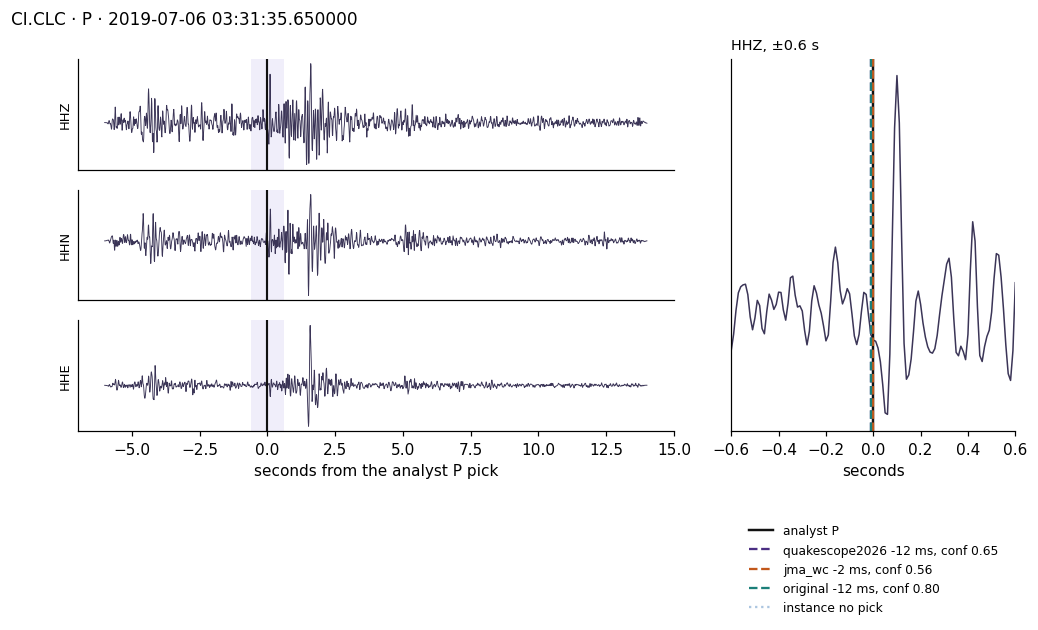

{'quakescope2026': (-0.011700153350830078, 0.6497458815574646),
 'jma_wc': (-0.0017001628875732422, 0.5597478747367859),
 'original': (-0.011700153350830078, 0.8022485971450806)}

In [7]:
def plot_arrival(st, arrival, station, phase, picks, thr=0.3, zoom=0.6, pad=6.0):
    t_ref = pd.Timestamp(arrival).timestamp()
    st = st.copy().detrend("demean").taper(0.02).filter("bandpass", freqmin=1.0, freqmax=20.0)
    comps = [tr for c in "ZNE" for tr in st.select(component=c)][:3]

    hits = {}
    for w in WEIGHTS:
        g = picks[(picks.station == station) & (picks.phase == phase)
                  & (picks.weights == w) & (picks.conf >= thr)]
        if g.empty:
            continue
        d = g.time.astype("int64") / 1e9 - t_ref
        j = d.abs().idxmin()
        if abs(d[j]) <= 0.5:
            hits[w] = (float(d[j]), float(g.conf[j]))

    fig = plt.figure(figsize=(11, 4.4))
    gs = fig.add_gridspec(len(comps), 2, width_ratios=[2.1, 1.0], wspace=0.13, hspace=0.18)
    for k, tr in enumerate(comps):
        ax = fig.add_subplot(gs[k, 0])
        t = tr.times() - pad
        ax.plot(t, tr.data / np.abs(tr.data).max(), color="#3b3557", lw=0.6)
        ax.axvline(0, color="#111", lw=1.4)
        ax.axvspan(-zoom, zoom, color="#6d5bd0", alpha=0.10, lw=0)
        ax.set_ylabel(tr.stats.channel, fontsize=8.5)
        ax.set_yticks([])
        if k < len(comps) - 1:
            ax.set_xticks([])
        else:
            ax.set_xlabel(f"seconds from the analyst {phase} pick")

    want = "Z" if phase == "P" else "NE12"
    tr = max([c for c in comps if c.stats.channel[-1] in want] or comps,
             key=lambda x: np.abs(x.data).max())
    t = tr.times() - pad
    m = (t >= -zoom) & (t <= zoom)
    az = fig.add_subplot(gs[:, 1])
    az.plot(t[m], tr.data[m] / np.abs(tr.data[m]).max(), color="#3b3557", lw=1.0)
    az.axvline(0, color="#111", lw=1.6, label=f"analyst {phase}")
    for w, (d, c) in hits.items():
        az.axvline(d, color=WCOLOR[w], lw=1.5, ls="--", label=f"{w} {d*1000:+.0f} ms, conf {c:.2f}")
    for w in WEIGHTS:
        if w not in hits:
            az.plot([], [], color=WCOLOR[w], ls=":", alpha=0.4, label=f"{w} no pick")
    az.set_xlim(-zoom, zoom); az.set_yticks([]); az.set_xlabel("seconds")
    az.set_title(f"{tr.stats.channel}, \u00b1{zoom:g} s", fontsize=9.5, loc="left")
    az.legend(frameon=False, fontsize=8, loc="lower center", bbox_to_anchor=(0.5, -0.52))
    fig.suptitle(f"{station} \u00b7 {phase} \u00b7 {arrival}", x=0.07, ha="left", fontsize=11)
    return fig, hits


fig, hits = plot_arrival(st, arrival, "CI.CLC", "P", picks)
plt.show()
hits

## 5. Scoring picks of your own

`scripts/score_picks.py` computes every metric the board reports, on any two
files with these columns. It needs only `numpy` and `pandas`.

```
python scripts/score_picks.py --reference arrivals.csv --picks mypicks.csv --out scores/
python scripts/score_picks.py --demo        # synthetic picks, no data needed
```

The published files are already in that format, so the command below reproduces
the board's own detection, timing, calibration and phase-quality tables.

In [8]:
# The same files, scored by the published scorer.
# !python scripts/score_picks.py \\
#     --reference {BASE}/us_sequences/reference_picks.csv \\
#     --picks     {BASE}/us_sequences/model_picks.csv \\
#     --out scores/
print("reference columns:", list(ref.columns))
print("picks columns    :", list(picks.columns))

reference columns: ['sequence', 'station', 'phase', 'time']
picks columns    : ['sequence', 'weights', 'station', 'phase', 'time', 'conf']


## Where the rest is

- the board itself: [https://seisscoped.org/QuakeScope/benchmark_metrics.html](https://seisscoped.org/QuakeScope/benchmark_metrics.html)
- how every number is computed: [methods notebook](benchmark_metrics_methods.html)
- the scorer: [`scripts/score_picks.py`](https://github.com/SeisSCOPED/QuakeScope/blob/main/scripts/score_picks.py)
- metric definitions: [`sb_catalog/src/benchmark_metrics.py`](https://github.com/SeisSCOPED/QuakeScope/blob/main/sb_catalog/src/benchmark_metrics.py)
- the example records on the board download as MiniSEED, one per figure